# AEGIS Data Audit and Feature Analysis

Project: Autonomous Energy Grid Intelligence System (AEGIS) — Edge AI based renewable energy monitoring, anomaly detection, federated learning evaluation, and ESP32 deployment.

# 01_data_audit

This notebook performs the initial data quality assessment and feature compatibility analysis for AEGIS.

The analysis includes:
- inspection of Wind Farm A SCADA datasets
- inspection of Vestas V52 reference data
- validation of duplicate and paired CSV structures
- feature similarity analysis for cross-site evaluation
- missing value and duplicate checks
- basic distribution drift assessment
- generation of audit tables and visual summaries

In [1]:
from pathlib import Path
import re
import json
from datetime import datetime
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
TABLES_DIR = PROJECT_ROOT / "tables"
PROCESSED_DIR = DATA_DIR / "processed"

for p in [DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR, PROCESSED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR     =", DATA_DIR)
print("TABLES_DIR   =", TABLES_DIR)
print("FIGURES_DIR  =", FIGURES_DIR)
print("RESULTS_DIR  =", RESULTS_DIR)

PROJECT_ROOT = C:\Users\MOINODHEEN\Moinu\Aegis_Project
DATA_DIR     = C:\Users\MOINODHEEN\Moinu\Aegis_Project\data
TABLES_DIR   = C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables
FIGURES_DIR  = C:\Users\MOINODHEEN\Moinu\Aegis_Project\figures
RESULTS_DIR  = C:\Users\MOINODHEEN\Moinu\Aegis_Project\results


In [3]:
path_check = pd.read_csv(TABLES_DIR / "00_path_check.csv")

PATHS = {}
for _, row in path_check.iterrows():
    key = row["key"]
    full_path = row["full_path"]
    if pd.isna(full_path) or str(full_path).strip() == "":
        PATHS[key] = None
    else:
        PATHS[key] = Path(full_path)

path_check

,key,full_path,exists
0,wind_feature_description,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,True
1,wind_event_info,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,True
2,wind_dataset_dir,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,True
3,vestas_excel,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\V...,True
4,pv_yield_excel,NaN,False
5,pv_fault_amb_mat,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\P...,True
6,pv_fault_elec_mat,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\P...,True
7,node1_log,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\l...,True
8,node1_log_clean,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\l...,True
9,node2_log,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\l...,True


In [4]:
def save_csv(df, filename, folder=TABLES_DIR, index=False):
    path = folder / filename
    df.to_csv(path, index=index)
    print("Saved CSV:", path)
    return path

def save_json(data, filename, folder=RESULTS_DIR):
    path = folder / filename
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, default=str)
    print("Saved JSON:", path)
    return path

def save_figure(fig, filename, folder=FIGURES_DIR, dpi=300, bbox_inches="tight"):
    path = folder / filename
    fig.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    print("Saved figure:", path)
    return path

def read_csv_auto(path, nrows=None, usecols=None):
    attempts = [
        {"sep": ","},
        {"sep": ";"},
        {"sep": None, "engine": "python"}
    ]
    best_df = None
    best_cols = -1

    for kw in attempts:
        try:
            df = pd.read_csv(path, nrows=nrows, usecols=usecols, **kw)
            if df.shape[1] > best_cols:
                best_df = df
                best_cols = df.shape[1]
        except Exception:
            pass

    if best_df is None:
        raise ValueError(f"Could not read CSV file: {path}")

    return best_df

def find_timestamp_column(df):
    candidates = [c for c in df.columns if any(k in str(c).lower() for k in ["time", "timestamp", "date"])]
    return candidates[0] if candidates else None

def normalize_name(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def keyword_group(text):
    t = normalize_name(text)
    if any(k in t for k in ["temp", "temperature", "bearing", "gearbox", "generator", "nacelle", "oil"]):
        return "temperature"
    if any(k in t for k in ["rpm", "speed", "rotor", "generator speed"]):
        return "rpm_speed"
    if any(k in t for k in ["power", "active power", "reactive power", "output"]):
        return "power"
    if any(k in t for k in ["wind", "windspeed", "wind speed"]):
        return "wind"
    if any(k in t for k in ["voltage", "current", "bus", "lux", "light"]):
        return "electrical_other"
    return "other"

In [7]:
feature_desc = read_csv_auto(PATHS["wind_feature_description"])
event_info = read_csv_auto(PATHS["wind_event_info"])

vestas_excel_path = PATHS["vestas_excel"]
vestas_book = pd.ExcelFile(vestas_excel_path)
vestas_sheet_name = vestas_book.sheet_names[0]
vestas_df = pd.read_excel(vestas_excel_path, sheet_name=vestas_sheet_name)

print("feature_desc shape:", feature_desc.shape)
print("event_info shape   :", event_info.shape)
print("vestas_df shape    :", vestas_df.shape)
print("vestas sheet name  :", vestas_sheet_name)

feature_desc shape: (54, 6)
event_info shape   : (22, 8)
vestas_df shape    : (653103, 22)
vestas sheet name  : Sheet1


In [8]:
display(feature_desc.head())
display(event_info.head())
display(vestas_df.head())

,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
1,sensor_1,average,Wind absolute direction,�,True,False
2,sensor_2,average,Wind relative direction,�,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False


,asset,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,11,68,anomaly,2023-07-28 13:20:00,52063,2023-08-11 13:10:00,54076,Transformer failure
1,21,22,anomaly,2023-08-12 09:50:00,51888,2023-08-19 10:00:00,52892,Hydraulic group
2,21,72,anomaly,2023-10-10 08:40:00,52497,2023-10-17 08:40:00,53505,Gearbox failure
3,0,73,anomaly,2023-06-10 11:40:00,52745,2023-06-17 11:40:00,53753,Hydraulic group
4,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure


,Timestamps,WindSpeed,StdDevWindSpeed,WindDirAbs,WindDirRel,Power,MaxPower,MinPower,StdDevPower,AvgRPow,Pitch,GenRPM,RotorRPM,EnvirTemp,NacelTemp,GearOilTemp,GearBearTemp,GenTemp,GenPh1Temp,GenPh2Temp,GenPh3Temp,GenBearTemp
0,2006-01-30 20:30:00,9.5,0.7,101.9,2.0,527.3,633.2,362.3,48.8,0.0,-1.2,1618,26.1,5,18,55,63,999,82,82,81,62
1,2006-01-30 20:40:00,9.9,0.9,107.1,2.5,584.5,731.5,353.3,74.6,0.0,-0.8,1618,26.1,5,18,57,65,999,86,85,85,64
2,2006-01-30 20:50:00,9.3,0.9,105.0,-0.5,527.3,728.1,291.1,92.7,0.0,-1.2,1604,25.9,4,17,57,65,999,89,88,88,64
3,2006-01-30 21:00:00,8.7,0.8,106.3,0.8,428.0,669.4,216.7,92.9,0.0,-1.7,1583,25.5,4,15,55,63,999,88,88,88,60
4,2006-01-30 21:10:00,8.6,0.8,103.5,-2.0,434.7,622.2,233.1,80.3,0.0,-1.7,1577,25.4,4,15,57,66,999,85,85,84,57


In [9]:
source_summary = pd.DataFrame([
    {
        "source": "Wind Farm A feature description",
        "path": str(PATHS["wind_feature_description"]),
        "rows": feature_desc.shape[0],
        "cols": feature_desc.shape[1]
    },
    {
        "source": "Wind Farm A event info",
        "path": str(PATHS["wind_event_info"]),
        "rows": event_info.shape[0],
        "cols": event_info.shape[1]
    },
    {
        "source": "Vestas V52 Excel first sheet",
        "path": str(PATHS["vestas_excel"]),
        "rows": vestas_df.shape[0],
        "cols": vestas_df.shape[1]
    }
])

save_csv(source_summary, "01_source_summary.csv")
source_summary

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_source_summary.csv


,source,path,rows,cols
0,Wind Farm A feature description,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,54,6
1,Wind Farm A event info,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,22,8
2,Vestas V52 Excel first sheet,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\V...,653103,22


In [11]:
wind_dir = PATHS["wind_dataset_dir"]
all_wind_files = sorted(wind_dir.glob("*.csv"), key=lambda p: p.name)

wind_inventory = pd.DataFrame({
    "file_name": [f.name for f in all_wind_files],
    "full_path": [str(f) for f in all_wind_files],
    "file_size_bytes": [f.stat().st_size for f in all_wind_files],
    "is_comma_version": [f.name.startswith("comma_") for f in all_wind_files],
    "event_id": [re.findall(r"\d+", f.stem)[0] if re.findall(r"\d+", f.stem) else None for f in all_wind_files]
})

save_csv(wind_inventory, "01_wind_inventory_full.csv")
wind_inventory.head(20)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_inventory_full.csv


,file_name,full_path,file_size_bytes,is_comma_version,event_id
0,0.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,36891572,False,0
1,10.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,35826430,False,10
2,13.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,36217983,False,13
3,14.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,36614003,False,14
4,17.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,36850928,False,17
5,22.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,35472117,False,22
6,24.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,36979351,False,24
7,25.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,36624095,False,25
8,26.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,36068832,False,26
9,3.csv,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,37088823,False,3


In [12]:
pair_rows = []
event_ids = sorted({x for x in wind_inventory["event_id"].dropna().unique()}, key=lambda x: int(x))

canonical_files = []

for event_id in event_ids:
    base_name = f"{event_id}.csv"
    comma_name = f"comma_{event_id}.csv"

    base_path = wind_dir / base_name
    comma_path = wind_dir / comma_name

    base_exists = base_path.exists()
    comma_exists = comma_path.exists()

    if base_exists:
        canonical_files.append(base_path)
    elif comma_exists:
        canonical_files.append(comma_path)

    pair_rows.append({
        "event_id": event_id,
        "base_file_exists": base_exists,
        "comma_file_exists": comma_exists,
        "canonical_file_used": str(base_path if base_exists else comma_path if comma_exists else "")
    })

pair_check = pd.DataFrame(pair_rows)
save_csv(pair_check, "01_wind_pair_check.csv")

print("Total wind csv files found:", len(all_wind_files))
print("Canonical wind event files :", len(canonical_files))
pair_check.head(20)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_pair_check.csv
Total wind csv files found: 44
Canonical wind event files : 22


,event_id,base_file_exists,comma_file_exists,canonical_file_used
0,0,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
1,3,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
2,10,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
3,13,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
4,14,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
5,17,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
6,22,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
7,24,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
8,25,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...
9,26,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...


In [13]:
pair_compare_rows = []

for _, row in pair_check.iterrows():
    event_id = row["event_id"]
    base_path = wind_dir / f"{event_id}.csv"
    comma_path = wind_dir / f"comma_{event_id}.csv"

    if base_path.exists() and comma_path.exists():
        df_base = read_csv_auto(base_path, nrows=5000)
        df_comma = read_csv_auto(comma_path, nrows=5000)

        pair_compare_rows.append({
            "event_id": event_id,
            "base_cols": df_base.shape[1],
            "comma_cols": df_comma.shape[1],
            "base_rows_sampled": df_base.shape[0],
            "comma_rows_sampled": df_comma.shape[0],
            "same_column_count": df_base.shape[1] == df_comma.shape[1],
            "same_column_names": list(df_base.columns) == list(df_comma.columns)
        })

pair_compare = pd.DataFrame(pair_compare_rows)
save_csv(pair_compare, "01_wind_pair_compare.csv")
pair_compare.head(20)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_pair_compare.csv


,event_id,base_cols,comma_cols,base_rows_sampled,comma_rows_sampled,same_column_count,same_column_names
0,0,86,86,5000,5000,True,True
1,3,86,86,5000,5000,True,True
2,10,86,86,5000,5000,True,True
3,13,86,86,5000,5000,True,True
4,14,86,86,5000,5000,True,True
5,17,86,86,5000,5000,True,True
6,22,86,86,5000,5000,True,True
7,24,86,86,5000,5000,True,True
8,25,86,86,5000,5000,True,True
9,26,86,86,5000,5000,True,True


In [14]:
wind_audit_rows = []

for file_path in canonical_files:
    df = read_csv_auto(file_path)
    ts_col = find_timestamp_column(df)

    duplicate_timestamp_count = None
    min_time = None
    max_time = None

    if ts_col is not None:
        ts = pd.to_datetime(df[ts_col], errors="coerce")
        duplicate_timestamp_count = int(ts.duplicated().sum())
        if ts.notna().any():
            min_time = str(ts.min())
            max_time = str(ts.max())

    wind_audit_rows.append({
        "file_name": file_path.name,
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "timestamp_column": ts_col,
        "duplicate_timestamps": duplicate_timestamp_count,
        "start_time": min_time,
        "end_time": max_time
    })

wind_file_audit = pd.DataFrame(wind_audit_rows)
save_csv(wind_file_audit, "01_wind_file_audit.csv")
wind_file_audit.head(20)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_file_audit.csv


,file_name,rows,cols,missing_cells,duplicate_rows,timestamp_column,duplicate_timestamps,start_time,end_time
0,0.csv,54986,86,2,0,time_stamp,0,2022-08-04 06:10:00,2023-08-24 06:10:00
1,3.csv,55487,86,4,0,time_stamp,0,2022-04-27 03:00:00,2023-05-20 01:10:00
2,10.csv,53592,86,6,0,time_stamp,0,2022-10-09 08:40:00,2023-10-18 08:40:00
3,13.csv,54010,86,0,0,time_stamp,0,2022-04-30 13:20:00,2023-05-25 10:20:00
4,14.csv,54197,86,0,0,time_stamp,0,2022-03-03 14:00:00,2023-03-16 18:40:00
5,17.csv,55090,86,6,0,time_stamp,0,2022-10-31 15:20:00,2023-11-20 00:40:00
6,22.csv,53036,86,2,0,time_stamp,0,2022-08-12 09:50:00,2023-08-20 09:50:00
7,24.csv,55003,86,0,0,time_stamp,0,2022-04-24 15:00:00,2023-05-13 11:20:00
8,25.csv,54712,86,0,0,time_stamp,0,2022-05-23 06:50:00,2023-06-09 02:30:00
9,26.csv,53702,86,2,0,time_stamp,0,2022-10-12 10:20:00,2023-10-22 10:20:00


In [15]:
wind_overall_summary = pd.DataFrame([{
    "canonical_file_count": int(len(canonical_files)),
    "total_rows_across_canonical_files": int(wind_file_audit["rows"].sum()),
    "median_rows_per_file": float(wind_file_audit["rows"].median()),
    "max_columns_seen": int(wind_file_audit["cols"].max()),
    "total_missing_cells": int(wind_file_audit["missing_cells"].sum()),
    "total_duplicate_rows": int(wind_file_audit["duplicate_rows"].sum()),
    "files_with_timestamp_column": int(wind_file_audit["timestamp_column"].notna().sum()),
    "feature_description_rows": int(feature_desc.shape[0]),
    "feature_description_cols": int(feature_desc.shape[1])
}])

save_csv(wind_overall_summary, "01_wind_overall_summary.csv")
wind_overall_summary

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_overall_summary.csv


,canonical_file_count,total_rows_across_canonical_files,median_rows_per_file,max_columns_seen,total_missing_cells,total_duplicate_rows,files_with_timestamp_column,feature_description_rows,feature_description_cols
0,22,1196747,54277.5,86,40,0,22,54,6


In [16]:
event_info_cols_lower = {c.lower(): c for c in event_info.columns}

possible_event_cols = [c for c in event_info.columns if "event" in c.lower() and "id" in c.lower()]
if not possible_event_cols:
    possible_event_cols = [c for c in event_info.columns if "event" in c.lower()]
event_id_col = possible_event_cols[0] if possible_event_cols else event_info.columns[0]

event_info_copy = event_info.copy()
event_info_copy["_event_id_str"] = event_info_copy[event_id_col].astype(str).str.extract(r"(\d+)")[0]

wind_event_metadata = pair_check.merge(
    event_info_copy,
    left_on="event_id",
    right_on="_event_id_str",
    how="left"
)

save_csv(wind_event_metadata, "01_wind_event_metadata_join.csv")
wind_event_metadata.head(20)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_event_metadata_join.csv


,event_id_x,base_file_exists,comma_file_exists,canonical_file_used,asset,event_id_y,event_label,event_start,event_start_id,event_end,event_end_id,event_description,_event_id_str
0,0,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,0,0,anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure,0
1,3,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,10,3,normal,2023-04-27 03:00:00,52185,2023-05-18 01:10:00,55198,NaN,3
2,10,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,10,10,anomaly,2023-10-11 08:40:00,52611,2023-10-18 08:40:00,53591,Gearbox failure,10
3,13,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,21,13,normal,2023-05-03 13:20:00,50859,2023-05-24 10:20:00,53865,NaN,13
4,14,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,13,14,normal,2023-03-05 14:00:00,52584,2023-03-12 18:40:00,53620,NaN,14
5,17,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,10,17,normal,2023-11-02 15:20:00,52597,2023-11-16 00:40:00,54513,NaN,17
6,22,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,21,22,anomaly,2023-08-12 09:50:00,51888,2023-08-19 10:00:00,52892,Hydraulic group,22
7,24,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,0,24,normal,2023-04-27 15:00:00,52720,2023-05-11 11:20:00,54714,NaN,24
8,25,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,11,25,normal,2023-05-23 06:50:00,52289,2023-06-05 02:30:00,54135,NaN,25
9,26,True,True,C:\Users\MOINODHEEN\Moinu\Aegis_Project\data\W...,0,26,anomaly,2023-10-12 10:20:00,52261,2023-10-19 10:20:00,53269,Hydraulic group,26


In [17]:
vestas_ts_col = find_timestamp_column(vestas_df)

vestas_start = None
vestas_end = None
vestas_dup_ts = None

if vestas_ts_col is not None:
    vestas_ts = pd.to_datetime(vestas_df[vestas_ts_col], errors="coerce")
    vestas_dup_ts = int(vestas_ts.duplicated().sum())
    if vestas_ts.notna().any():
        vestas_start = str(vestas_ts.min())
        vestas_end = str(vestas_ts.max())

vestas_audit = pd.DataFrame([{
    "sheet_name": vestas_sheet_name,
    "rows": int(vestas_df.shape[0]),
    "cols": int(vestas_df.shape[1]),
    "missing_cells": int(vestas_df.isna().sum().sum()),
    "duplicate_rows": int(vestas_df.duplicated().sum()),
    "timestamp_column": vestas_ts_col,
    "duplicate_timestamps": vestas_dup_ts,
    "start_time": vestas_start,
    "end_time": vestas_end
}])

save_csv(vestas_audit, "01_vestas_audit.csv")
vestas_audit

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_vestas_audit.csv


,sheet_name,rows,cols,missing_cells,duplicate_rows,timestamp_column,duplicate_timestamps,start_time,end_time
0,Sheet1,653103,22,0,0,Timestamps,20,2006-01-30 20:30:00,2020-03-12 12:20:00


In [18]:
vestas_columns = pd.DataFrame({
    "vestas_column": vestas_df.columns.astype(str),
    "normalized_name": [normalize_name(c) for c in vestas_df.columns],
    "keyword_group": [keyword_group(c) for c in vestas_df.columns]
})

save_csv(vestas_columns, "01_vestas_columns.csv")
vestas_columns.head(30)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_vestas_columns.csv


,vestas_column,normalized_name,keyword_group
0,Timestamps,timestamps,other
1,WindSpeed,windspeed,rpm_speed
2,StdDevWindSpeed,stddevwindspeed,rpm_speed
3,WindDirAbs,winddirabs,wind
4,WindDirRel,winddirrel,wind
5,Power,power,power
6,MaxPower,maxpower,power
7,MinPower,minpower,power
8,StdDevPower,stddevpower,power
9,AvgRPow,avgrpow,other


In [19]:
first_wind_df = read_csv_auto(canonical_files[0])

wind_columns = pd.DataFrame({
    "wind_column": first_wind_df.columns.astype(str),
    "normalized_name": [normalize_name(c) for c in first_wind_df.columns],
    "keyword_group": [keyword_group(c) for c in first_wind_df.columns]
})

save_csv(wind_columns, "01_wind_columns.csv")
wind_columns.head(40)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_columns.csv


,wind_column,normalized_name,keyword_group
0,time_stamp,time stamp,other
1,asset_id,asset id,other
2,id,id,other
3,train_test,train test,other
4,status_type_id,status type id,other
5,sensor_0_avg,sensor 0 avg,other
6,sensor_1_avg,sensor 1 avg,other
7,sensor_2_avg,sensor 2 avg,other
8,wind_speed_3_avg,wind speed 3 avg,rpm_speed
9,wind_speed_4_avg,wind speed 4 avg,rpm_speed


In [20]:
mapping_rows = []

for vestas_col in vestas_df.columns:
    vestas_norm = normalize_name(vestas_col)
    best_match = None
    best_score = -1

    for wind_col in first_wind_df.columns:
        score = SequenceMatcher(None, vestas_norm, normalize_name(wind_col)).ratio()
        if score > best_score:
            best_score = score
            best_match = wind_col

    mapping_rows.append({
        "vestas_column": str(vestas_col),
        "wind_best_match": str(best_match),
        "similarity_score": round(float(best_score), 4),
        "vestas_group": keyword_group(vestas_col),
        "wind_group": keyword_group(best_match),
        "same_group": keyword_group(vestas_col) == keyword_group(best_match)
    })

feature_overlap = pd.DataFrame(mapping_rows).sort_values(
    by=["same_group", "similarity_score"], ascending=[False, False]
).reset_index(drop=True)

save_csv(feature_overlap, "01_feature_overlap_candidates.csv")
feature_overlap.head(40)

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_feature_overlap_candidates.csv


,vestas_column,wind_best_match,similarity_score,vestas_group,wind_group,same_group
0,Timestamps,time_stamp,0.9000,other,other,True
1,WindSpeed,wind_speed_3_avg,0.7200,rpm_speed,rpm_speed,True
2,Power,power_29_avg,0.5882,power,power,True
3,StdDevWindSpeed,wind_speed_3_avg,0.5806,rpm_speed,rpm_speed,True
4,MaxPower,power_29_avg,0.5000,power,power,True
5,MinPower,power_29_avg,0.5000,power,power,True
6,StdDevPower,reactive_power_27_avg,0.4375,power,power,True
7,Pitch,id,0.2857,other,other,True
8,GenTemp,time_stamp,0.4706,temperature,other,False
9,WindDirAbs,wind_speed_3_avg,0.4615,wind,rpm_speed,False


In [21]:
priority_groups = ["temperature", "rpm_speed", "power", "wind"]

selected_pairs = []
for grp in priority_groups:
    sub = feature_overlap[
        (feature_overlap["vestas_group"] == grp) &
        (feature_overlap["wind_group"] == grp)
    ].sort_values("similarity_score", ascending=False)

    if len(sub) > 0:
        selected_pairs.append(sub.iloc[0].to_dict())

selected_pairs_df = pd.DataFrame(selected_pairs)
save_csv(selected_pairs_df, "01_selected_feature_pairs.csv")
selected_pairs_df

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_selected_feature_pairs.csv


,vestas_column,wind_best_match,similarity_score,vestas_group,wind_group,same_group
0,WindSpeed,wind_speed_3_avg,0.7200,rpm_speed,rpm_speed,True
1,Power,power_29_avg,0.5882,power,power,True


In [22]:
sampled_wind_parts = []

selected_wind_cols = [x for x in selected_pairs_df["wind_best_match"].tolist() if x in first_wind_df.columns]

for file_path in canonical_files:
    try:
        df = read_csv_auto(file_path, usecols=selected_wind_cols)
        for c in selected_wind_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df = df.dropna(how="all")
        if len(df) > 1500:
            df = df.sample(1500, random_state=42)
        sampled_wind_parts.append(df)
    except Exception:
        pass

wind_sample = pd.concat(sampled_wind_parts, ignore_index=True) if sampled_wind_parts else pd.DataFrame()

selected_vestas_cols = [x for x in selected_pairs_df["vestas_column"].tolist() if x in vestas_df.columns]
vestas_sample = vestas_df[selected_vestas_cols].copy()

for c in selected_vestas_cols:
    vestas_sample[c] = pd.to_numeric(vestas_sample[c], errors="coerce")

if len(vestas_sample) > 20000:
    vestas_sample = vestas_sample.sample(20000, random_state=42)

print("wind_sample shape  :", wind_sample.shape)
print("vestas_sample shape:", vestas_sample.shape)

wind_sample shape  : (33000, 2)
vestas_sample shape: (20000, 2)


Saved figure: C:\Users\MOINODHEEN\Moinu\Aegis_Project\figures\01_wind_vs_vestas_distributions.png


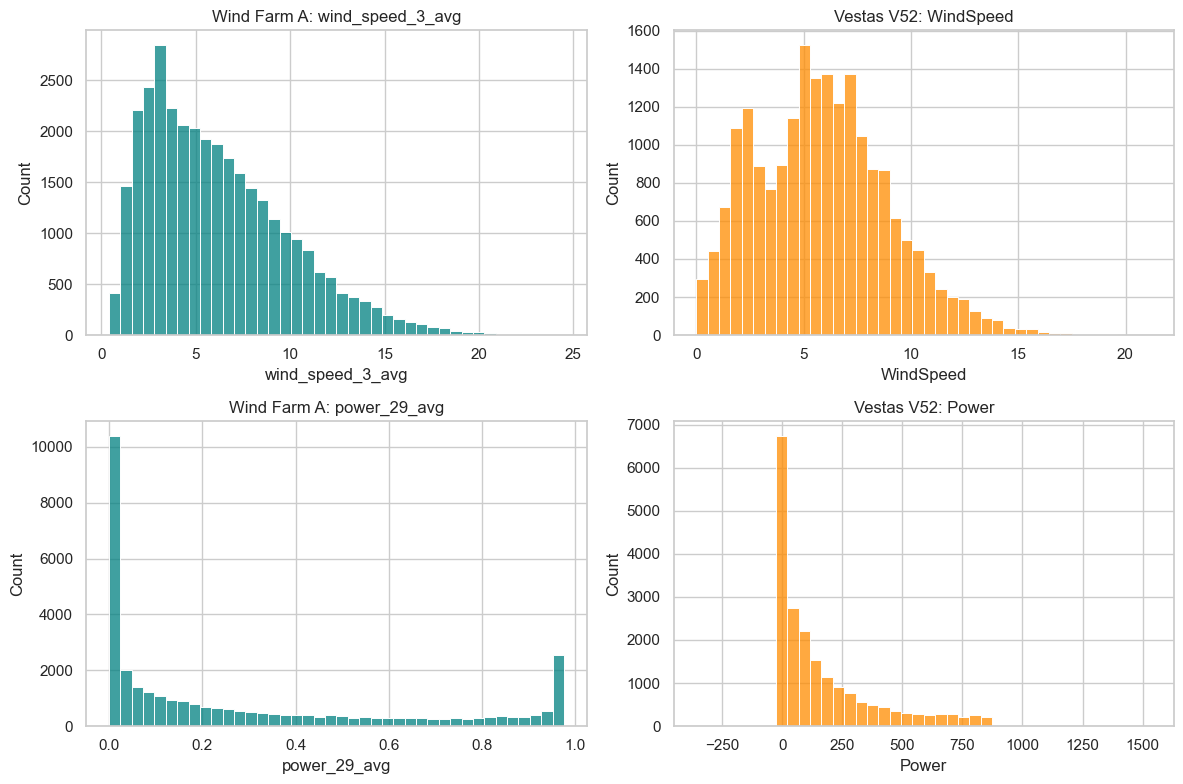

In [23]:
if len(selected_pairs_df) == 0:
    print("No matched feature pairs found strongly enough for plotting.")
else:
    n = len(selected_pairs_df)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = np.array([axes])

    for i, row in selected_pairs_df.reset_index(drop=True).iterrows():
        wcol = row["wind_best_match"]
        vcol = row["vestas_column"]

        w = pd.to_numeric(wind_sample[wcol], errors="coerce").dropna()
        v = pd.to_numeric(vestas_sample[vcol], errors="coerce").dropna()

        sns.histplot(w, bins=40, ax=axes[i, 0], color="teal")
        axes[i, 0].set_title(f"Wind Farm A: {wcol}")

        sns.histplot(v, bins=40, ax=axes[i, 1], color="darkorange")
        axes[i, 1].set_title(f"Vestas V52: {vcol}")

    plt.tight_layout()
    save_figure(fig, "01_wind_vs_vestas_distributions.png")
    plt.show()

In [24]:
drift_rows = []

if len(selected_wind_cols) > 0 and len(wind_sample) > 10:
    drift_df = wind_sample.copy().reset_index(drop=True)

    split_idx = int(len(drift_df) * 0.8)
    drift_train = drift_df.iloc[:split_idx]
    drift_test = drift_df.iloc[split_idx:]

    for col in selected_wind_cols:
        x = pd.to_numeric(drift_train[col], errors="coerce").dropna()
        y = pd.to_numeric(drift_test[col], errors="coerce").dropna()

        if len(x) > 10 and len(y) > 10:
            ks_stat, ks_p = ks_2samp(x, y)
            drift_rows.append({
                "feature": col,
                "train_mean": float(x.mean()),
                "test_mean": float(y.mean()),
                "train_std": float(x.std()),
                "test_std": float(y.std()),
                "ks_statistic": float(ks_stat),
                "ks_p_value": float(ks_p)
            })

wind_drift = pd.DataFrame(drift_rows)
save_csv(wind_drift, "01_wind_drift_check.csv")
wind_drift

Saved CSV: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\01_wind_drift_check.csv


,feature,train_mean,test_mean,train_std,test_std,ks_statistic,ks_p_value
0,wind_speed_3_avg,6.198682,6.263955,3.723780,3.794950,0.010947,0.547843
1,power_29_avg,0.287178,0.294750,0.332766,0.338608,0.013106,0.321844


Saved figure: C:\Users\MOINODHEEN\Moinu\Aegis_Project\figures\01_wind_missing_by_file.png


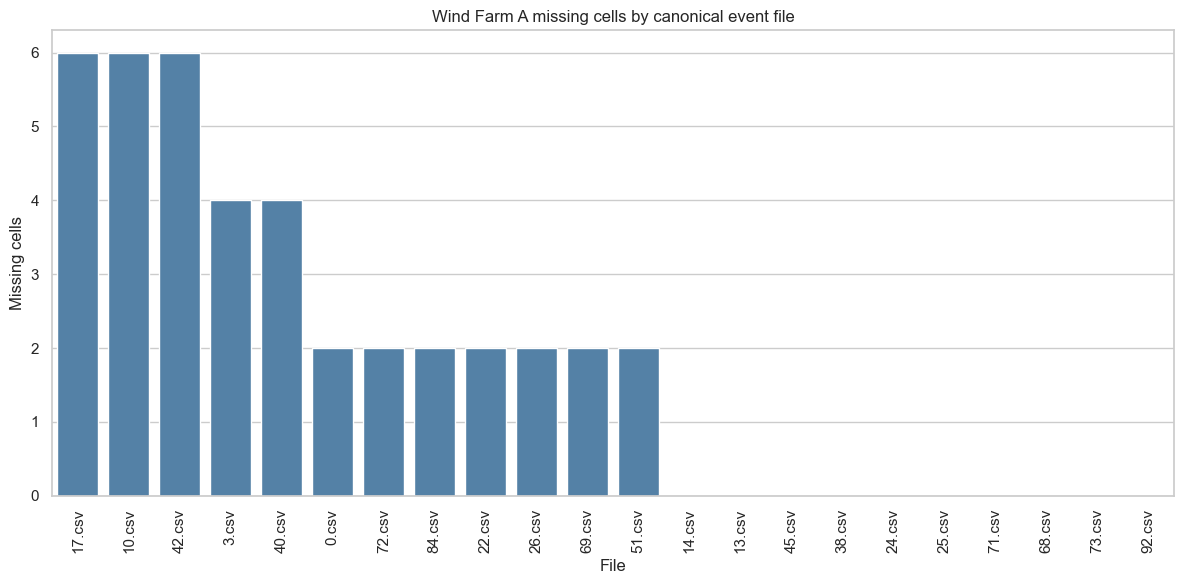

In [25]:
wind_missing = wind_file_audit[["file_name", "missing_cells"]].copy().sort_values("missing_cells", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=wind_missing, x="file_name", y="missing_cells", ax=ax, color="steelblue")
ax.set_title("Wind Farm A missing cells by canonical event file")
ax.set_xlabel("File")
ax.set_ylabel("Missing cells")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
save_figure(fig, "01_wind_missing_by_file.png")
plt.show()

In [ ]:
audit_summary = {
    "notebook": "01_data_audit",
    "timestamp": datetime.now().isoformat(),
    "canonical_wind_files": int(len(canonical_files)),
    "all_wind_csv_files_found": int(len(all_wind_files)),
    "paired_comma_comparison_rows": int(len(pair_compare)),
    "wind_total_rows": int(wind_file_audit["rows"].sum()),
    "wind_max_columns": int(wind_file_audit["cols"].max()),
    "vestas_rows": int(vestas_df.shape[0]),
    "vestas_cols": int(vestas_df.shape[1]),
    "selected_feature_pairs": int(len(selected_pairs_df))
}

save_json(audit_summary, "01_data_audit_summary.json")
audit_summary

Saved JSON: C:\Users\MOINODHEEN\Moinu\Aegis_Project\results\01_data_audit_summary.json


{'notebook': '01_data_audit.ipynb',
 'timestamp': '2026-04-02T21:28:43.018517',
 'canonical_wind_files': 22,
 'all_wind_csv_files_found': 44,
 'paired_comma_comparison_rows': 22,
 'wind_total_rows': 1196747,
 'wind_max_columns': 86,
 'vestas_rows': 653103,
 'vestas_cols': 22,
 'selected_distribution_pairs': 2}

In [27]:
print("01_data_audit complete.")

01_data_audit complete.
